In [17]:
!pip install mygene

In [18]:
import pandas as pd
import mygene

# Load limma result for the key comparison
res_sm_vs_am = pd.read_csv("/workspaces/Malaria-host-response-systems/data/processed/limma_voom_symptomatic_vs_asymptomatic.csv")

# The GeneID column contains Entrez IDs as strings. Convert to list.
entrez_ids = res_sm_vs_am['GeneID'].astype(str).tolist()

# Initialize mygene object
mg = mygene.MyGeneInfo()

# Query gene symbols for all IDs in batch (returns list of dicts)
gene_info = mg.querymany(entrez_ids, scopes='entrezgene', fields='symbol', species='human', verbose=False)

# Create a mapping dictionary: Entrez ID -> symbol
id_to_symbol = {}
for entry in gene_info:
    if 'symbol' in entry:
        id_to_symbol[entry['query']] = entry['symbol']

# Add a new column 'Symbol' to the results DataFrame
res_sm_vs_am['Symbol'] = res_sm_vs_am['GeneID'].astype(str).map(id_to_symbol)

# Display top 20 genes by adjusted p-value (BH per contrast)
top_genes = res_sm_vs_am.sort_values('adj.P.Val').head(20)
print(top_genes[['GeneID', 'Symbol', 'logFC', 'AveExpr', 'adj.P.Val']])

          GeneID    Symbol     logFC   AveExpr  adj.P.Val
891         1870      E2F2  1.708635  5.152966   0.000255
603         1191       CLU  2.974810  5.945431   0.026834
8070       55165     CEP55  2.382853  1.970288   0.056430
14875  100996941  IL21-AS1  4.208965 -1.366450   0.056430
4057        8745    ADAM23 -2.791441  0.736052   0.076174
7670       54414      SIAE  0.866245  3.998982   0.090368
11100     113130     CDCA5  1.756169  2.605510   0.090368
4720        9837     GINS1  1.597989  1.396692   0.090368
7711       54498      SMOX  2.389022  3.926095   0.090368
3698        7832      BTG2 -0.973413  7.975118   0.090368
4761        9886   RHOBTB1  2.192348  2.547767   0.090368
6995       29116     MYLIP -1.078107  6.460408   0.090368
9624       79667  KLF3-AS1 -1.388059  3.108156   0.090368
4717        9833      MELK  2.128496  1.517644   0.090368
7001       29127   RACGAP1  0.965805  3.537070   0.090368
1797        4001     LMNB1  1.286027  6.501709   0.090368
4916       101

In [19]:
genes_of_interest = ['IFNG', 'CXCL9', 'SLAMF7', 'LAG3', 'CTLA4', 'BTG1', 'IRF2BP2', 'NR1D1']
res_sm_vs_am[res_sm_vs_am['Symbol'].isin(genes_of_interest)][['Symbol', 'logFC', 'adj.P.Val', 'GeneID']]

,Symbol,logFC,adj.P.Val,GeneID
337,BTG1,-0.633635,0.144943,694
729,CTLA4,0.760037,0.333871,1493
1554,IFNG,0.562503,0.679875,3458
1746,LAG3,1.613822,0.138969,3902
1933,CXCL9,3.053346,0.130392,4283
4523,NR1D1,-1.394891,0.175011,9572
9012,SLAMF7,1.054266,0.151530,57823
13209,IRF2BP2,-0.666465,0.147957,359948


Now Let’s Generate PCA, Sample Distance, and Heatmap Plots
Step 1: Load and filter counts

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform

# Load full counts and metadata
counts_full = pd.read_csv("/workspaces/Malaria-host-response-systems/data/processed/count_matrix_integer.txt", sep='\t', index_col=0)
metadata = pd.read_csv("/workspaces/Malaria-host-response-systems/data/processed/sample_metadata_aligned.csv", index_col=0)
counts_full = counts_full[metadata.index]

# CPM filter
lib_sizes = counts_full.sum(axis=0)
cpm = counts_full.div(lib_sizes, axis=1) * 1e6
keep = (cpm >= 0.5).sum(axis=1) >= 5
counts_filt = counts_full[keep]
print("Filtered count matrix:", counts_filt.shape)

# Log2-CPM
log2cpm = np.log2(counts_filt.div(counts_filt.sum(axis=0), axis=1) * 1e6 + 1)

Filtered count matrix: (16110, 17)


Step 2: PCA plot

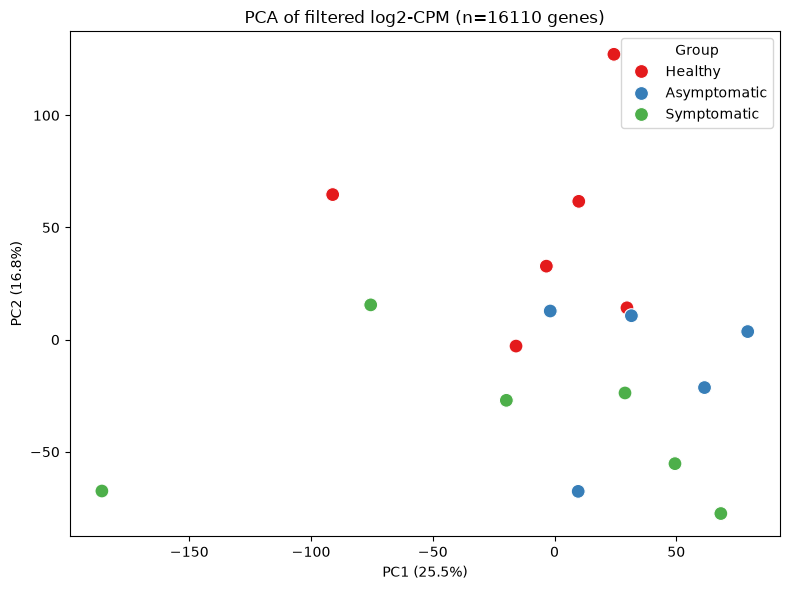

In [21]:
pca_input = log2cpm.T
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_input)
pca = PCA(n_components=2)
pcs = pca.fit_transform(pca_scaled)
pca_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'], index=log2cpm.columns)
pca_df = pca_df.join(metadata)

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='group', s=100, palette='Set1')
plt.title(f'PCA of filtered log2-CPM (n={counts_filt.shape[0]} genes)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(title='Group')
plt.tight_layout()
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/PCA_limma_filtered.png', dpi=150)
plt.show()

Steo 3: Sample distance heatmap

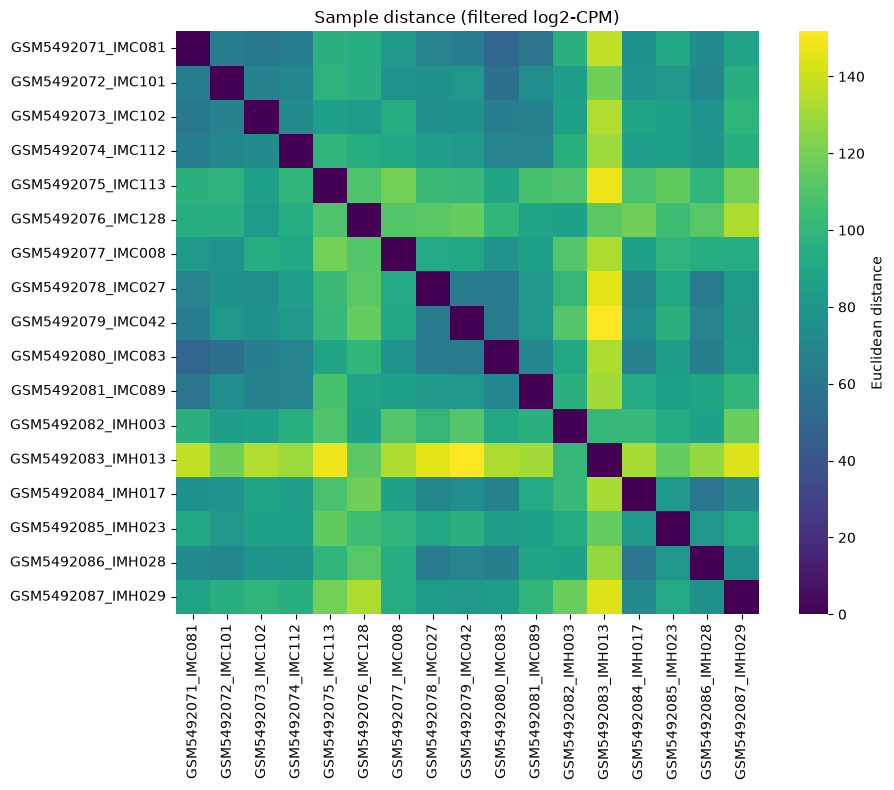

In [22]:
dist = pdist(log2cpm.T, metric='euclidean')
dist_sq = squareform(dist)
dist_df = pd.DataFrame(dist_sq, index=log2cpm.columns, columns=log2cpm.columns)

plt.figure(figsize=(10,8))
sns.heatmap(dist_df, cmap='viridis', square=True, cbar_kws={'label': 'Euclidean distance'})
plt.title('Sample distance (filtered log2-CPM)')
plt.tight_layout()
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/sample_distance_heatmap.png', dpi=150)
plt.show()

Step 4: Heatmap of top 50 DE genes (Symptomatic vs Asymptomatic)
First, ensure res_sm_vs_am is loaded (with Symbol column). We’ll select the top 50 genes by adj.P.Val, extract their expression, and cluster.

In [23]:
# Load the original limma result
base_file = "/workspaces/Malaria-host-response-systems/data/processed/limma_voom_symptomatic_vs_asymptomatic.csv"
res = pd.read_csv(base_file)

# Map Entrez IDs to symbols
mg = mygene.MyGeneInfo()
entrez_ids = res['GeneID'].astype(str).tolist()
gene_info = mg.querymany(entrez_ids, scopes='entrezgene', fields='symbol', species='human', verbose=False)

id_to_symbol = {}
for entry in gene_info:
    if 'symbol' in entry:
        id_to_symbol[entry['query']] = entry['symbol']

res['Symbol'] = res['GeneID'].astype(str).map(id_to_symbol)

# Save the enriched file
res.to_csv("/workspaces/Malaria-host-response-systems/data/processed/limma_voom_symptomatic_vs_asymptomatic_with_symbols.csv", index=False)
print("Saved enriched file with symbols.")
print(res.head())

Saved enriched file with symbols.
   GeneID     logFC   AveExpr         t   P.Value  adj.P.Val         B Symbol
0       1 -0.508628  1.988668 -0.842495  0.410394   0.734956 -5.592960   A1BG
1       2 -0.878591  0.892943 -1.927259  0.069626   0.396628 -4.156083    A2M
2       3 -1.719433 -0.829719 -2.463915  0.023865   0.282972 -3.251802    NaN
3       9  0.744340  2.661231  2.552377  0.019837   0.266566 -3.272779   NAT1
4      14  0.110203  6.493281  0.755594  0.459514   0.764881 -6.223788   AAMP


In [24]:
res_sm_vs_am = pd.read_csv("/workspaces/Malaria-host-response-systems/data/processed/limma_voom_symptomatic_vs_asymptomatic_with_symbols.csv")
top50 = res_sm_vs_am.sort_values('adj.P.Val').head(50)
top50_ids = top50['GeneID'].astype(str).tolist()

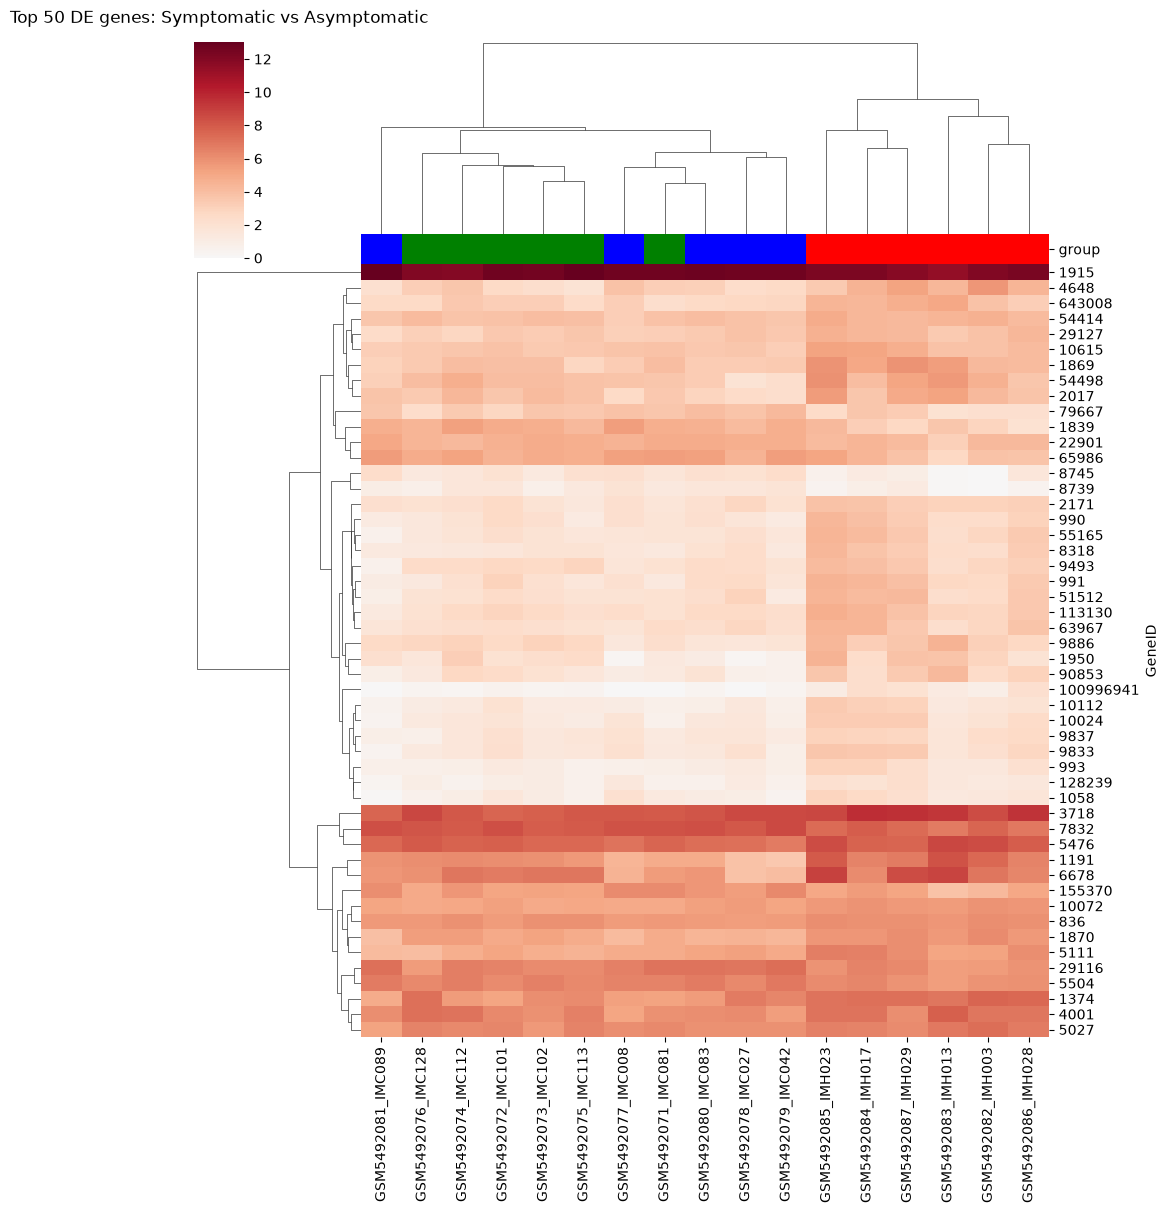

In [29]:
# Ensure log2cpm and metadata are defined
# If not, run the earlier cell that loads/filters counts and computes log2cpm.

# Get valid gene IDs that are present in log2cpm index
valid_ids = [g for g in top50_ids if g in log2cpm.index]
top50_expr = log2cpm.loc[valid_ids]

# Column colors
group_colors = {'Healthy': 'green', 'Asymptomatic': 'blue', 'Symptomatic': 'red'}
col_colors = metadata['group'].map(group_colors)

# Plot clustermap
sns.clustermap(top50_expr, cmap='RdBu_r', center=0,
               col_colors=col_colors, figsize=(10,12),
               yticklabels=True, xticklabels=True)
plt.title('Top 50 DE genes: Symptomatic vs Asymptomatic', y=1.05)
plt.savefig('/workspaces/Malaria-host-response-systems/results/figures/heatmap_top50_sm_vs_am.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
log2cpm.index = log2cpm.index.astype(str)